In [1]:
%matplotlib widget

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("weather.csv.gz")

In [4]:
df["date"] = pd.to_datetime(df["date"])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df

,date,stn,Station Name,CTRY_ISO,wban,temp,prcp,wdsp,visib,slp,sndp,dewp,mxpsd,month,year
0,2020-01-01,910660,HENDERSON FIELD AIRPORT,UM,22701,16.777778,0.254,16.6680,16093.4400,1023.4,NaN,8.500000,25.9280,1,2020
1,2020-01-01,720699,CARROLL CO RGNL/JJACK B POAGE FIELD AIRPORT,US,3724,5.166667,0.000,18.1496,16093.4400,NaN,NaN,-3.555556,25.9280,1,2020
2,2020-01-01,476000,WAJIMA,JP,99999,4.277778,13.970,11.4824,17863.7184,1024.5,NaN,1.555556,18.3348,1,2020
3,2020-01-01,998015,WELLS RESERVE,US,99999,1.333333,0.000,10.3712,NaN,NaN,NaN,-2.166667,16.4828,1,2020
4,2020-01-01,999999,NaN,NaN,126,3.888889,0.000,4.0744,NaN,NaN,NaN,-1.833333,25.9280,1,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16241440,2023-12-31,727454,GRAND MARAIS/COOK CO ARPT,US,4911,-8.500000,NaN,16.1124,11426.3424,NaN,NaN,-10.388889,31.6692,12,2023
16241441,2023-12-31,477880,HOFU,JP,99999,9.555556,NaN,17.4088,9334.1952,NaN,NaN,4.166667,37.0400,12,2023
16241442,2023-12-31,997799,SISTERS ISLAND,US,99999,3.555556,0.000,11.6676,NaN,NaN,NaN,-0.722222,27.7800,12,2023
16241443,2023-12-31,560460,DARLAG,CN,99999,-9.666667,0.000,3.5188,18829.3248,1033.0,NaN,-24.777778,7.2228,12,2023


In [5]:
NO = df[df["Station Name"]=="OLSZTYN"]

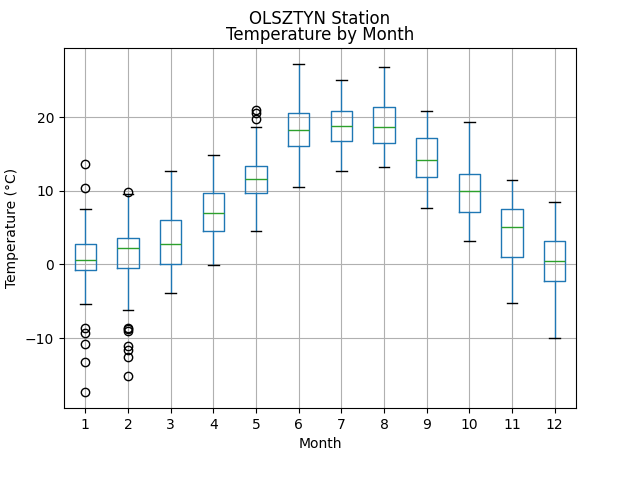

In [6]:
NO.boxplot("temp", by="month")
plt.title("Temperature by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

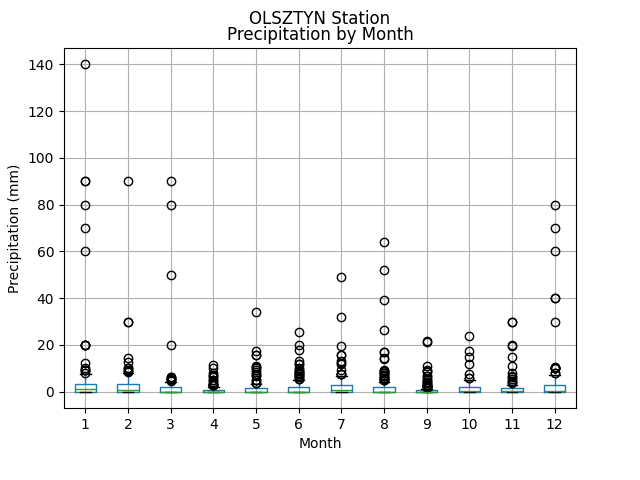

In [7]:
NO.boxplot("prcp", by="month")
plt.title("Precipitation by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

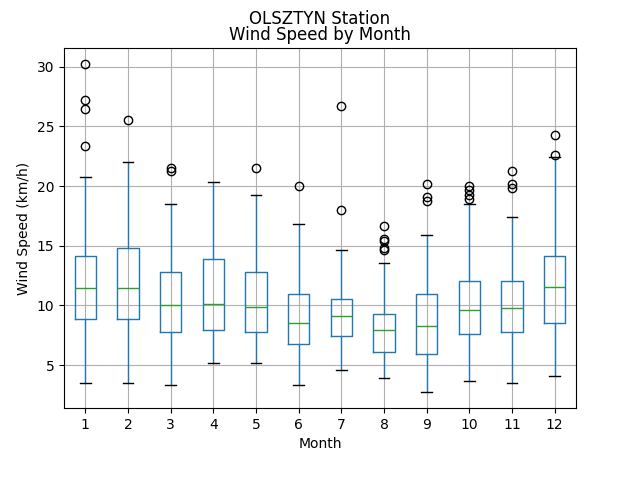

In [8]:
NO.boxplot("wdsp", by="month")
plt.title("Wind Speed by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Wind Speed (km/h)")
plt.show()

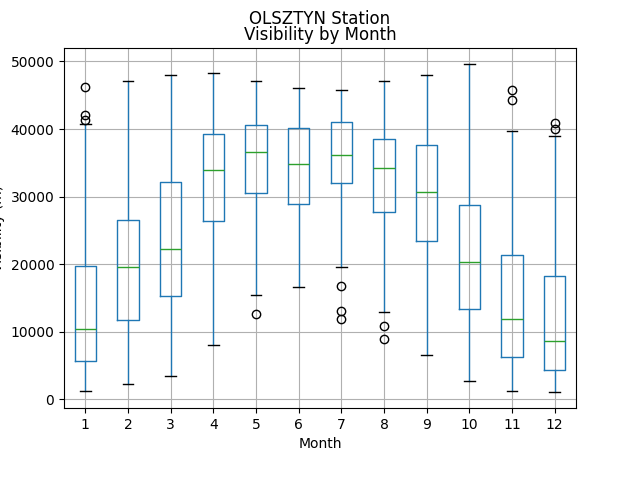

In [9]:
NO.boxplot("visib", by="month")
plt.title("Visibility by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Visibility (m)")
plt.show()

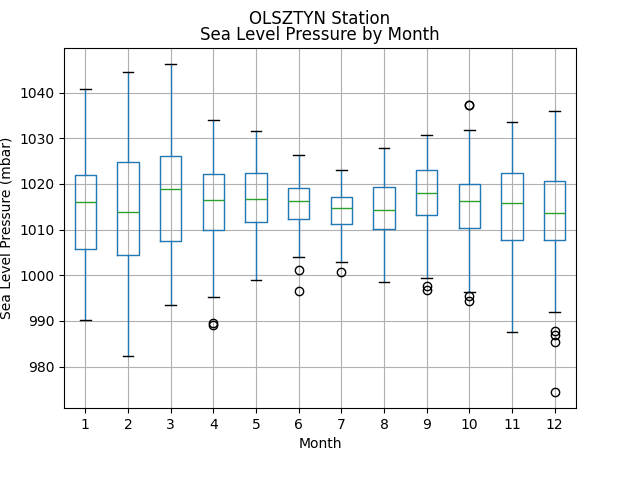

In [10]:
NO.boxplot("slp", by="month")
plt.title("Sea Level Pressure by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Sea Level Pressure (mbar)")
plt.show()

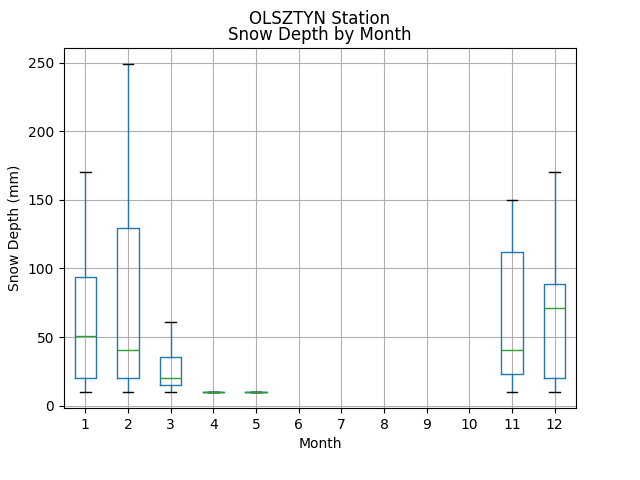

In [11]:
NO.boxplot("sndp", by="month")
plt.title("Snow Depth by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Snow Depth (mm)")
plt.show()

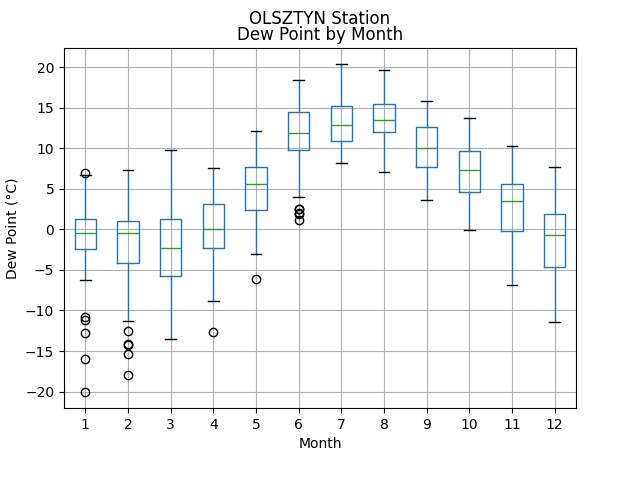

In [12]:
NO.boxplot("dewp", by="month")
plt.title("Dew Point by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Dew Point (°C)")
plt.show()

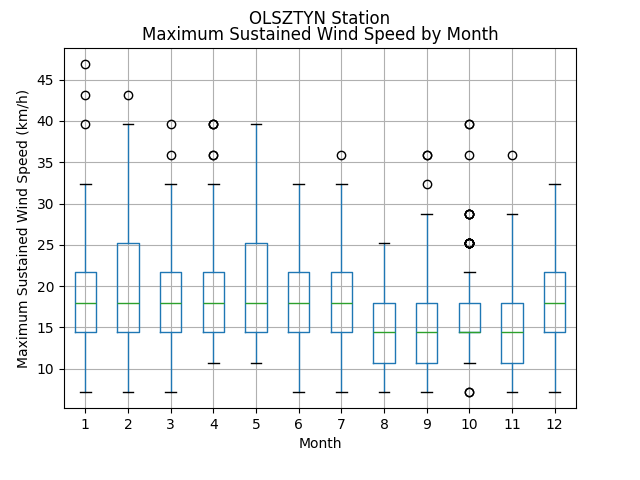

In [13]:
NO.boxplot("mxpsd", by="month")
plt.title("Maximum Sustained Wind Speed by Month")
plt.suptitle("OLSZTYN Station")
plt.xlabel("Month")
plt.ylabel("Maximum Sustained Wind Speed (km/h)")
plt.show()

In [14]:
NO[["prcp", "wdsp", "visib", "slp", "sndp", "dewp", "mxpsd"]].describe()

,prcp,wdsp,visib,slp,sndp,dewp,mxpsd
count,1387.000000,1459.000000,1459.000000,1459.000000,100.000000,1457.000000,1459.000000
mean,2.788140,10.262162,25506.392679,1015.362029,64.160400,4.791047,17.625861
std,9.331566,3.856408,12618.483265,9.284051,55.859728,7.028282,5.978603
min,0.000000,2.778000,1126.540800,974.500000,10.160000,-20.000000,7.222800
25%,0.000000,7.408000,15288.768000,1009.800000,20.320000,-0.444444,14.445600
50%,0.000000,9.630400,26876.044800,1015.900000,40.640000,4.611111,17.964400
75%,2.032000,12.408400,36371.174400,1021.300000,88.900000,10.444444,21.668400
max,139.954000,30.187600,49567.795200,1046.200000,248.920000,20.333333,46.855600


3. 1. Zidentyfikuj brakujące wartości w zbiorze, sprawdź liczbę braków w poszczególnych kolumnach oraz określ ich udział procentowy,

In [15]:
weather_cols = ['temp', 'prcp', 'wdsp', 'visib', 'slp', 'sndp', 'dewp', 'mxpsd']

nan_count = df[weather_cols].isna().sum()
nan_percent = df[weather_cols].isna().mean() * 100

nan_summary = pd.DataFrame({
    'NaN_count': nan_count,
    'NaN_percent': nan_percent
})

nan_summary

,NaN_count,NaN_percent
temp,0,0.000000
prcp,1248231,7.685468
wdsp,611841,3.767159
visib,4271191,26.298097
slp,5614099,34.566499
sndp,15125940,93.131738
dewp,764878,4.709421
mxpsd,833144,5.129741


3. 2. Sprawdź, czy w zbiorze występują wartości liczbowe oznaczające brak danych i w razie potrzeby zamień je na wartości brakujące,

In [16]:
max_value = df[weather_cols].max()
isna_value = df[weather_cols].isna().sum()
nan_summary = pd.DataFrame({
    'Max_value': max_value,
    'NaN_count': isna_value
})
nan_summary

,Max_value,NaN_count
temp,43.333333,0
prcp,489.966000,1248231
wdsp,157.234800,611841
visib,144840.960000,4271191
slp,1077.700000,5614099
sndp,2989.580000,15125940
dewp,32.222222,764878
mxpsd,179.458800,833144


3. 3. Wybierz co najmniej dwie zmienne pogodowe i uzupełnij brakujące wartości stosując różne metody imputacji: średnia, mediana, interpolacja w czasie, 

In [17]:
new_df = df[(df['date'] >= '2020-01-01') & (df['date'] <= '2020-12-31')].copy()
new_df['date'] = pd.to_datetime(new_df['date'])
new_df = new_df.set_index('date')
new_df = new_df.sort_index()

new_df['slp_mean'] = new_df['slp'].fillna(new_df['slp'].mean())
new_df['slp_median'] = new_df['slp'].fillna(new_df['slp'].median())
new_df['slp_interp'] = new_df['slp'].interpolate(method='time')

new_df['prcp_mean'] = new_df['prcp'].fillna(new_df['prcp'].mean())
new_df['prcp_median'] = new_df['prcp'].fillna(new_df['prcp'].median())
new_df['prcp_interp'] = new_df['prcp'].interpolate(method='time')

3. 4. Porównaj otrzymane wyniki dla różnych metod imputacji i uzasadnij wybór metody, którą uznasz za najbardziej odpowiednią. 

<Axes: title={'center': 'Sea Level Pressure Imputation Methods'}, xlabel='date'>

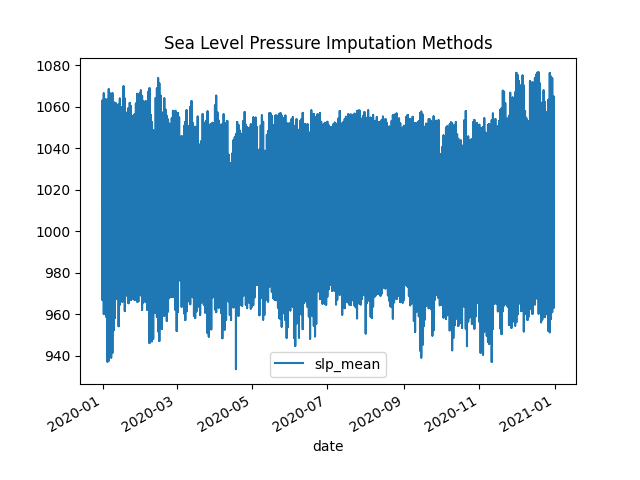

In [18]:
new_df.plot(use_index=True, y=['slp_mean'], title='Sea Level Pressure Imputation Methods')

<Axes: title={'center': 'Sea Level Pressure Imputation Methods'}, xlabel='date'>

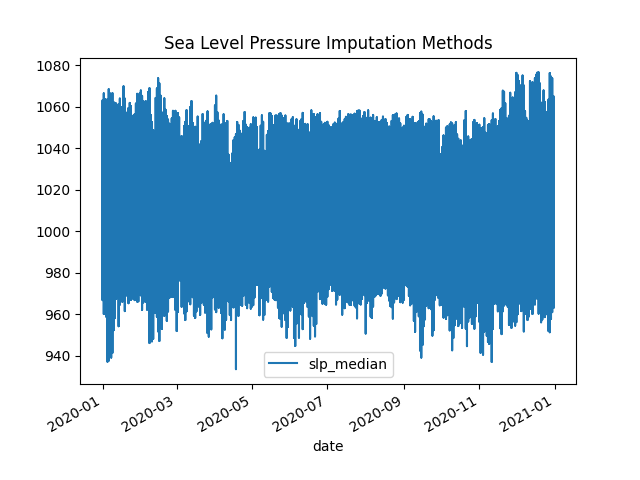

In [19]:
new_df.plot(use_index=True, y=['slp_median'], title='Sea Level Pressure Imputation Methods')

<Axes: title={'center': 'Sea Level Pressure Imputation Methods'}, xlabel='date'>

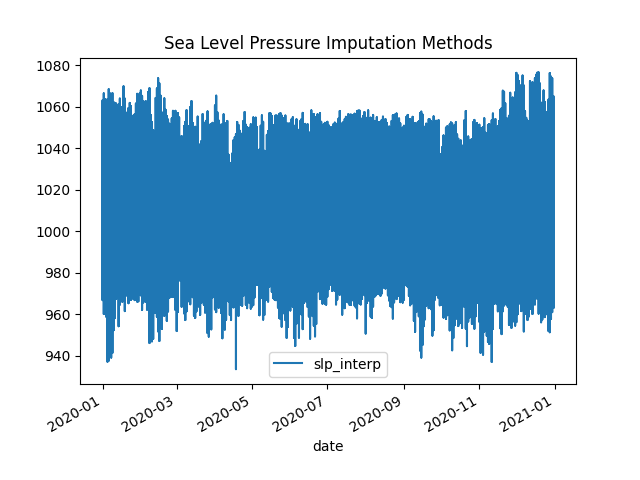

In [20]:
new_df.plot(use_index=True, y=['slp_interp'], title='Sea Level Pressure Imputation Methods')

4. 1.  średnia temperatura, opady i prędkość wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,

In [21]:
df_month = df[(df['date'].dt.year == 2020) & (df['date'].dt.month == 7)]

stations = df_month['Station Name'].dropna().unique()[:10]
df_selected = df_month[df_month['Station Name'].isin(stations)]

stats = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].describe(percentiles=[])

stats.T

Station Name  BAIYUN INTL  CASA GRANDE MUNICIPAL ARPT  \
temp count      31.000000                   30.000000   
     mean       31.383513                   35.470370   
     std         1.506594                    2.735608   
     min        27.611111                   29.722222   
     50%        31.611111                   35.750000   
     max        33.500000                   41.500000   
prcp count      31.000000                   30.000000   
     mean        2.171290                    0.000000   
     std         4.825928                    0.000000   
     min         0.000000                    0.000000   
     50%         0.000000                    0.000000   
     max        18.542000                    0.000000   
wdsp count      31.000000                   30.000000   
     mean       11.822929                   11.513267   
     std         3.362658                    2.817981   
     min         6.482000                    6.667200   
     50%        11.482400                   11.297200   
     max        17.779200                   18.890400   

Station Name  CHARLES CITY MUNICIPAL APT  CHEROKEE COUNTY AIRPORT  \
temp count                     30.000000                62.000000   
     mean                      23.596296                26.675627   
     std                        2.630823                 1.555985   
     min                       17.500000                22.166667   
     50%                       23.944444                26.722222   
     max                       27.055556                30.055556   
prcp count                     29.000000                38.000000   
     mean                       1.313793                 0.000000   
     std                        4.747087                 0.000000   
     min                        0.000000                 0.000000   
     50%                        0.000000                 0.000000   
     max                       24.384000                 0.000000   
wdsp count                     30.000000                62.000000   
     mean                      11.537960                 5.078065   
     std                        4.494850                 3.046387   
     min                        4.074400                 0.555600   
     50%                       12.223200                 4.537400   
     max                       21.668400                13.334400   

Station Name  JONESBORO MUNICIPAL ARPT  LUMPARLAND LANGNAS HARBOUR       LUQA  \
temp count                   28.000000                   31.000000  31.000000   
     mean                    28.232143                   16.198925  26.648746   
     std                      1.218949                    1.921814   1.495355   
     min                     25.944444                   12.111111  24.722222   
     50%                     28.111111                   15.833333  26.333333   
     max                     30.777778                   20.333333  30.111111   
prcp count                   28.000000                   31.000000  31.000000   
     mean                     1.759857                    1.564968   0.000000   
     std                      4.729187                    3.878859   0.000000   
     min                      0.000000                    0.000000   0.000000   
     50%                      0.000000                    0.000000   0.000000   
     max                     18.288000                   20.066000   0.000000   
wdsp count                   27.000000                   30.000000  31.000000   
     mean                    10.309467                   17.229773  12.587626   
     std                      3.952788                    4.664100   4.913326   
     min                      3.704000                    7.963600   7.593200   
     50%                     10.000800                   16.205000  11.297200   
     max                     21.483200                   28.706000  25.742800   

Station Name  OCEAN COUNTY AIRPORT  ROGNSUNDET   SMITHERS  
temp

4. 2. średnia zmiana temperatury i opadów dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,

In [22]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
df_selected['temp_diff'] = df_selected.groupby('Station Name')['temp'].diff()
df_selected['prcp_diff'] = df_selected.groupby('Station Name')['prcp'].diff()

mean_changes = df_selected.groupby('Station Name')[['temp_diff','prcp_diff']].mean()

mean_changes

/tmp/ipykernel_11290/1052372273.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['temp_diff'] = df_selected.groupby('Station Name')['temp'].diff()
/tmp/ipykernel_11290/1052372273.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['prcp_diff'] = df_selected.groupby('Station Name')['prcp'].diff()


,temp_diff,prcp_diff
Station Name,,
BAIYUN INTL,-0.009259,0.152400
CASA GRANDE MUNICIPAL ARPT,0.388889,0.000000
CHARLES CITY MUNICIPAL APT,-0.137931,-0.056444
CHEROKEE COUNTY AIRPORT,0.088342,0.000000
JONESBORO MUNICIPAL ARPT,-0.012346,0.649111
LUMPARLAND LANGNAS HARBOUR,0.051852,-0.033867
LUQA,0.098148,0.000000
OCEAN COUNTY AIRPORT,0.092593,0.166077
ROGNSUNDET,0.242593,0.000000


4. 3. mediana temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu, 

In [23]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
median_values = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].median()
median_values

,temp,prcp,wdsp
Station Name,,,
BAIYUN INTL,31.611111,0.0,11.4824
CASA GRANDE MUNICIPAL ARPT,35.750000,0.0,11.2972
CHARLES CITY MUNICIPAL APT,23.944444,0.0,12.2232
CHEROKEE COUNTY AIRPORT,26.722222,0.0,4.5374
JONESBORO MUNICIPAL ARPT,28.111111,0.0,10.0008
LUMPARLAND LANGNAS HARBOUR,15.833333,0.0,16.2050
LUQA,26.333333,0.0,11.2972
OCEAN COUNTY AIRPORT,25.777778,0.0,8.7044
ROGNSUNDET,11.555556,0.0,18.7052


4.4. odchylenie standardowe temperatury, opadów i prędkości wiatru,

In [24]:
df_selected = df_month[df_month['Station Name'].isin(stations)]
std_values = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].std().round(2)
std_values

,temp,prcp,wdsp
Station Name,,,
BAIYUN INTL,1.51,4.83,3.36
CASA GRANDE MUNICIPAL ARPT,2.74,0.00,2.82
CHARLES CITY MUNICIPAL APT,2.63,4.75,4.49
CHEROKEE COUNTY AIRPORT,1.56,0.00,3.05
JONESBORO MUNICIPAL ARPT,1.22,4.73,3.95
LUMPARLAND LANGNAS HARBOUR,1.92,3.88,4.66
LUQA,1.50,0.00,4.91
OCEAN COUNTY AIRPORT,2.26,10.27,2.88
ROGNSUNDET,4.01,0.00,6.70


4. 5. minimalna, średnia i maksymalna temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów,

In [25]:
summary_stats = df_selected.groupby('Station Name')[['temp','prcp','wdsp']].agg(['min','mean','max']).round(2)
summary_stats

temp               prcp               wdsp  \
                              min   mean    max  min  mean    max   min   
Station Name                                                              
BAIYUN INTL                 27.61  31.38  33.50  0.0  2.17  18.54  6.48   
CASA GRANDE MUNICIPAL ARPT  29.72  35.47  41.50  0.0  0.00   0.00  6.67   
CHARLES CITY MUNICIPAL APT  17.50  23.60  27.06  0.0  1.31  24.38  4.07   
CHEROKEE COUNTY AIRPORT     22.17  26.68  30.06  0.0  0.00   0.00  0.56   
JONESBORO MUNICIPAL ARPT    25.94  28.23  30.78  0.0  1.76  18.29  3.70   
LUMPARLAND LANGNAS HARBOUR  12.11  16.20  20.33  0.0  1.56  20.07  7.96   
LUQA                        24.72  26.65  30.11  0.0  0.00   0.00  7.59   
OCEAN COUNTY AIRPORT        20.94  25.63  30.17  0.0  3.23  53.85  3.52   
ROGNSUNDET                   6.11  12.22  19.89  0.0  0.00   0.00  9.07   
SMITHERS                    10.94  14.73  20.56  0.0  1.89  11.18  3.52   

                                          
                             mean    max  
Station Name                              
BAIYUN INTL                 11.82  17.78  
CASA GRANDE MUNICIPAL ARPT  11.51  18.89  
CHARLES CITY MUNICIPAL APT  11.54  21.67  
CHEROKEE COUNTY AIRPORT      5.08  13.33  
JONESBORO MUNICIPAL ARPT    10.31  21.48  
LUMPARLAND LANGNAS HARBOUR  17.23  28.71  
LUQA                        12.59  25.74  
OCEAN COUNTY AIRPORT         8.97  14.45  
ROGNSUNDET                  19.72  33.89  
SMITHERS                     7.02  12.96

Skorzystaj ze swojego połączonego zbioru danych (pogoda + rolnictwo) i oblicz średnią temperaturę oraz sumę opadów w wybranym roku dla co najmniej 10 krajów, a następnie porównaj te wartości z produkcją lub plonem wybranej rośliny w tych krajach. Spróbuj ocenić, czy można zauważyć zależność pomiędzy warunkami pogodowymi a produkcją rolną.

In [26]:
final = pd.read_csv("final.csv.gz")
final["date"] = pd.to_datetime(final["date"])
final = final.set_index(['CTRY_ISO', 'date'])
final

temp       prcp       wdsp  Abaca, manila hemp, raw  \
CTRY_ISO date                                                                   
AE       2020-01-01  20.916667   0.000000   9.584100                      NaN   
         2020-01-02  21.770833   0.000000   8.380300                      NaN   
         2020-01-03  22.416667   0.000000   8.218250                      NaN   
         2020-01-04  23.090278   0.000000  11.366650                      NaN   
         2020-01-05  23.500000   0.000000  17.570850                      NaN   
...                        ...        ...        ...                      ...   
ZW       2023-12-27  20.475309  20.955000   9.445200                      NaN   
         2023-12-28  20.074074  25.456444   9.795022                      NaN   
         2023-12-29  21.292929   0.000000  11.280364                      NaN   
         2023-12-30  22.029915   8.128000   9.046308                      NaN   
         2023-12-31  23.648148   0.677333   8.550067                      NaN   

                     Agave fibres, raw, n.e.c.  Almonds, in shell  \
CTRY_ISO date                                                       
AE       2020-01-01                        NaN             7857.1   
         2020-01-02                        NaN             7857.1   
         2020-01-03                        NaN             7857.1   
         2020-01-04                        NaN             7857.1   
         2020-01-05                        NaN             7857.1   
...                                        ...                ...   
ZW       2023-12-27                        NaN                NaN   
         2023-12-28                        NaN                NaN   
         2023-12-29                        NaN                NaN   
         2023-12-30                        NaN                NaN   
         2023-12-31                        NaN                NaN   

                     Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw  \
CTRY_ISO date                                                                                    
AE       2020-01-01                                                NaN                           
         2020-01-02                                                NaN                           
         2020-01-03                                                NaN                           
         2020-01-04                                                NaN                           
         2020-01-05                                                NaN                           
...                                                                ...                           
ZW       2023-12-27                                              738.1                           
         2023-12-28                                              738.1                           
         2023-12-29                                              738.1                           
         2023-12-30                                              738.1                           
         2023-12-31                                              738.1                           

                      Apples  Apricots  Areca nuts  ...  \
CTRY_ISO date                                       ...   
AE       2020-01-01      NaN       NaN         NaN  ...   
         2020-01-02      NaN       NaN         NaN  ...   
         2020-01-03      NaN       NaN         NaN  ...   
         2020-01-04      NaN       NaN         NaN  ...   
         2020-01-05      NaN       NaN         NaN  ...   
...                      ...       ...         ...  ...   
ZW       2023-12-27  24902.9    1994.4         NaN  ...   
         2023-12-28  24902.9    1994.4         NaN  ...   
         2023-12-29  24902.9    1994.4         NaN  ...   
         2023-12-30  24902.9    1994.4         NaN  ...   
         2023-12-31  24902.9    1994.4         NaN  ...   

                     True hemp,

In [27]:
year = 2020
df_year = final[final.index.get_level_values('date').year == year]

countries = ['PL', 'DE', 'BR', 'AU', 'US', 'IN', 'CH', 'CA', 'FR', 'ES']
df_selected = df_year.loc[countries]

weather_stats = df_selected.groupby(level='CTRY_ISO')[['temp','prcp']].agg({
    'temp':'mean',
    'prcp':'sum'
}).round(2)

crop = 'Apples'
# w każdym dniu roku jest suma z całego roku więc możemy zrobić mean()
# gdyby było wiele lat to trzebaby grupować po roku
crop_stats = df_selected.groupby(level='CTRY_ISO')[[crop]].mean().round(2).div(1000)


combined = weather_stats.join(crop_stats)
combined

,temp,prcp,Apples
CTRY_ISO,,,
AU,18.71,768.39,15.9435
BR,23.98,132.80,30.2829
CA,2.49,507.85,25.5739
CH,5.65,1015.62,64.5881
DE,11.00,212.53,30.1154
ES,16.17,612.56,17.7043
FR,13.45,693.62,31.8655
IN,25.98,1577.47,9.0774
PL,9.75,636.57,23.2975


/tmp/ipykernel_11290/1819132584.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(combined['temp'][i]+1, combined[crop][i], country)


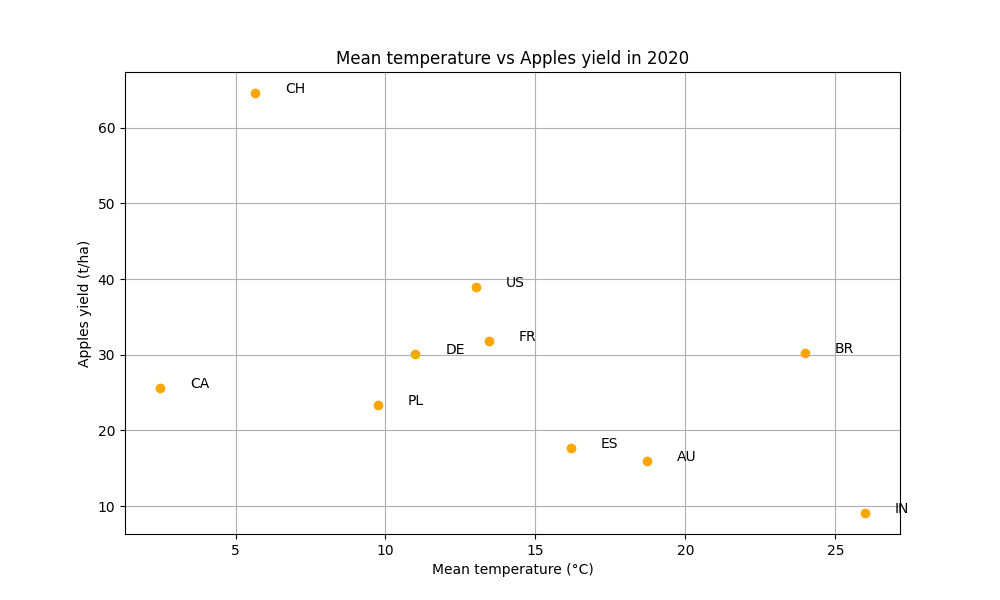

In [28]:
plt.figure(figsize=(10,6))
plt.scatter(combined['temp'], combined[crop], color='orange')
for i, country in enumerate(combined.index):
    plt.text(combined['temp'][i]+1, combined[crop][i], country)
plt.xlabel('Mean temperature (°C)')
plt.ylabel(f'{crop} yield (t/ha)')
plt.title(f'Mean temperature vs {crop} yield in {year}')
plt.grid(True)
plt.show()

/tmp/ipykernel_11290/4053237945.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(combined['prcp'][i]+1, combined[crop][i], country)


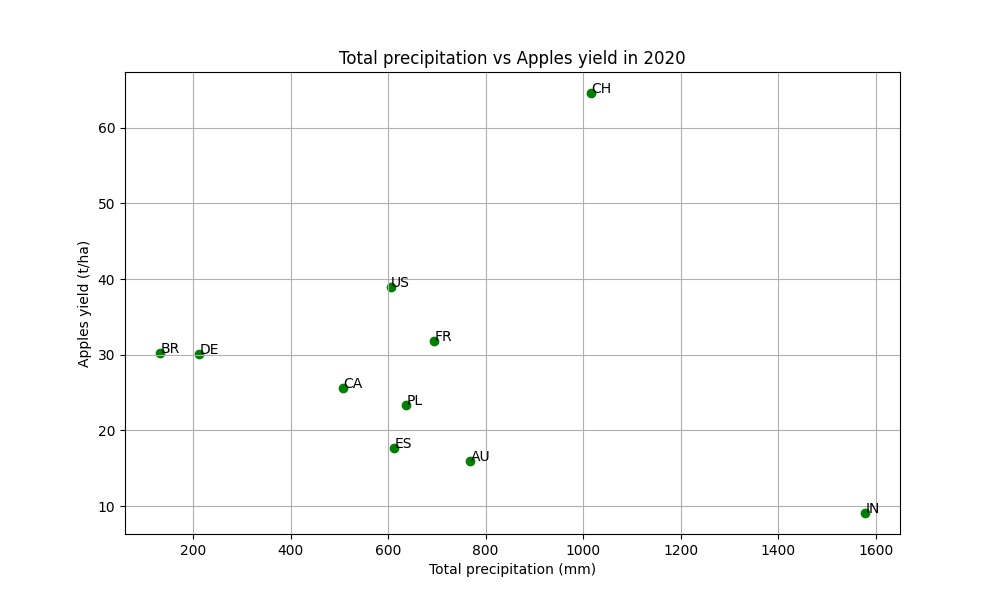

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(combined['prcp'], combined[crop], color='green')
for i, country in enumerate(combined.index):
    plt.text(combined['prcp'][i]+1, combined[crop][i], country)
plt.xlabel('Total precipitation (mm)')
plt.ylabel(f'{crop} yield (t/ha)')
plt.title(f'Total precipitation vs {crop} yield in {year}')
plt.grid(True)
plt.show()

Normalizacja danych 

5. 1.  Dla podanych kolumn

In [30]:
from sklearn.preprocessing import MinMaxScaler

cols_to_normalize = ['temp','prcp','wdsp','Apples','Watermelons','Wheat','Yams']
scaler = MinMaxScaler(feature_range=(0,1))

df_selected[cols_to_normalize] = scaler.fit_transform(df_selected[cols_to_normalize])

df_selected[cols_to_normalize]

temp      prcp      wdsp    Apples  Watermelons  \
CTRY_ISO date                                                              
PL       2020-01-01  0.419209  0.009016  0.408987  0.256169          NaN   
         2020-01-02  0.398835  0.000089  0.295956  0.256169          NaN   
         2020-01-03  0.415831  0.002917  0.396630  0.256169          NaN   
         2020-01-04  0.440988  0.070092  0.610603  0.256169          NaN   
         2020-01-05  0.391375  0.096403  0.399194  0.256169          NaN   
...                       ...       ...       ...       ...          ...   
ES       2020-12-27  0.506179  0.012465  0.315945  0.155410          1.0   
         2020-12-28  0.553539  0.130296  0.527248  0.155410          1.0   
         2020-12-29  0.524038  0.077585  0.352039  0.155410          1.0   
         2020-12-30  0.509350  0.105163  0.291322  0.155410          1.0   
         2020-12-31  0.514177  0.060129  0.273698  0.155410          1.0   

                        Wheat  Yams  
CTRY_ISO date                        
PL       2020-01-01  0.511710   NaN  
         2020-01-02  0.511710   NaN  
         2020-01-03  0.511710   NaN  
         2020-01-04  0.511710   NaN  
         2020-01-05  0.511710   NaN  
...                       ...   ...  
ES       2020-12-27  0.326427   NaN  
         2020-12-28  0.326427   NaN  
         2020-12-29  0.326427   NaN  
         2020-12-30  0.326427   NaN  
         2020-12-31  0.326427   NaN  

[3660 rows x 7 columns]

5. Wykresy porównawcze

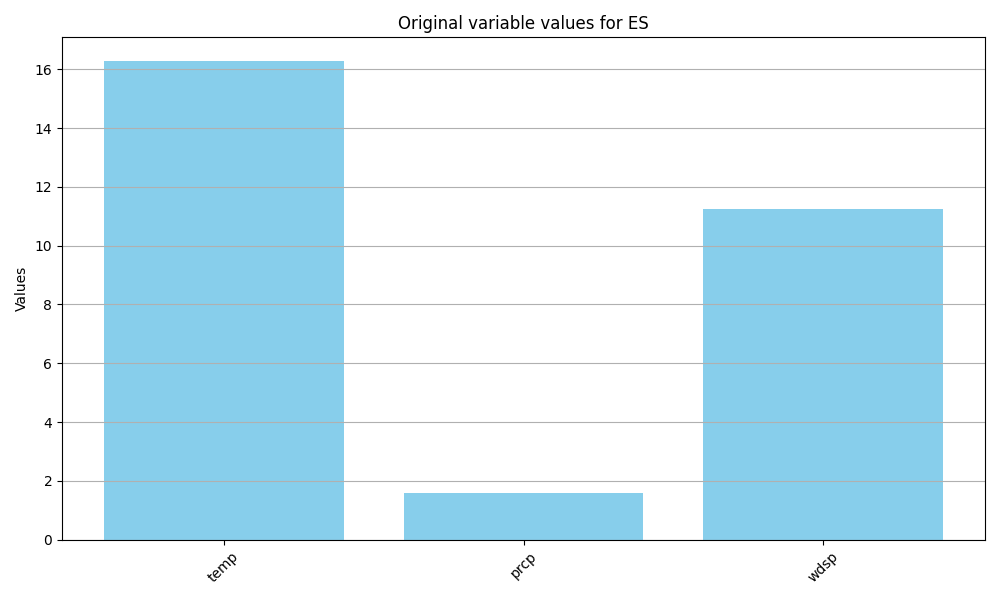

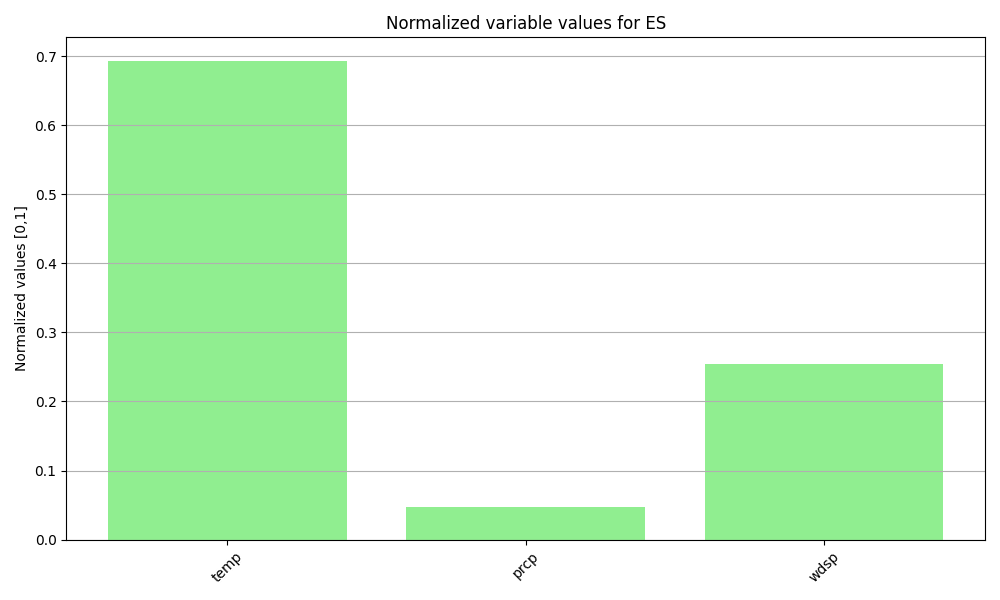

In [31]:
country = 'ES'

original = final.loc[country, ['temp','prcp','wdsp']].mean()

normalized = df_selected.loc[country, ['temp','prcp','wdsp']].mean()

plt.figure(figsize=(10,6))
plt.bar(original.index, original.values, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.title(f'Original variable values for {country}')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.bar(normalized.index, normalized.values, color='lightgreen')
plt.xticks(rotation=45)
plt.ylabel('Normalized values [0,1]')
plt.title(f'Normalized variable values for {country}')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

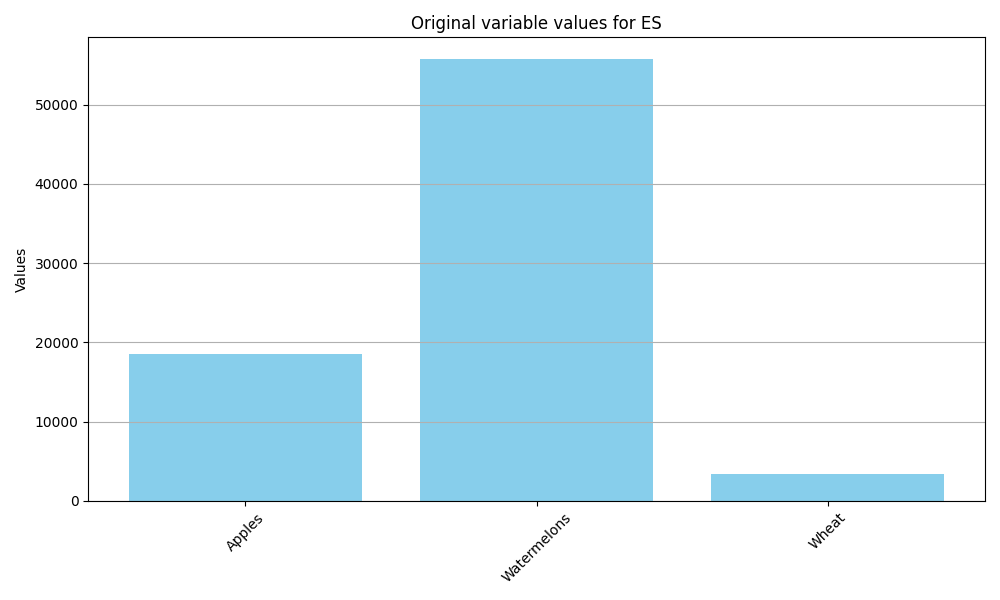

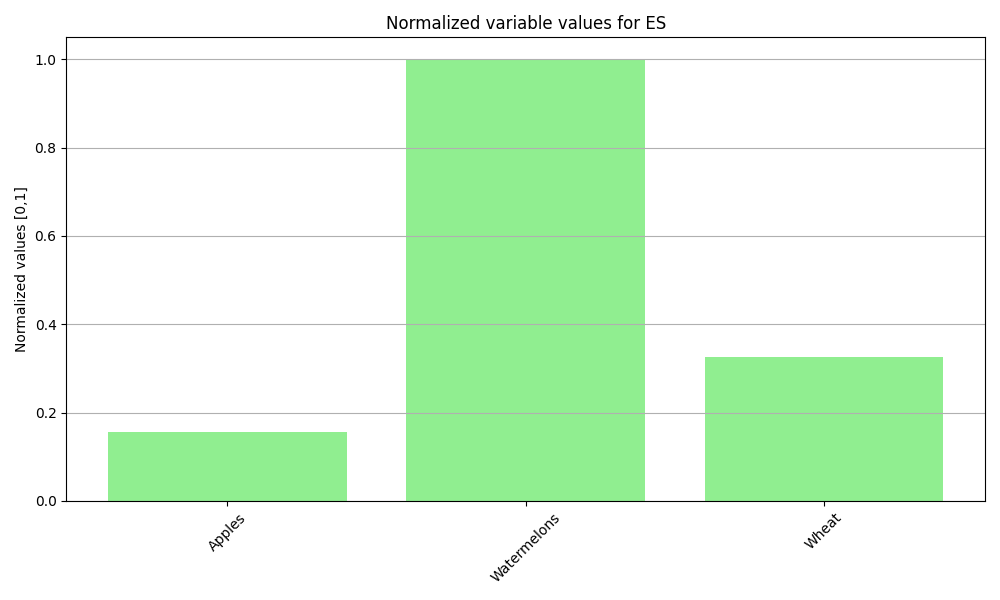

In [32]:
original = final.loc[country, ['Apples','Watermelons','Wheat','Yams']].mean()

normalized = df_selected.loc[country, ['Apples','Watermelons','Wheat','Yams']].mean()

plt.figure(figsize=(10,6))
plt.bar(original.index, original.values, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Values')
plt.title(f'Original variable values for {country}')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.bar(normalized.index, normalized.values, color='lightgreen')
plt.xticks(rotation=45)
plt.ylabel('Normalized values [0,1]')
plt.title(f'Normalized variable values for {country}')
plt.grid(axis='y')
plt.tight_layout()
plt.show()